#### Step 0 — Create Folder Structure

In [40]:
from pathlib import Path

global_path = Path("..//reports//figures//shap//global")
local_path = Path("..//reports//figures//shap//local")
dependence_path = Path("../reports//figures//shap//dependence")

tables_path = Path("../reports//tables")

explanations_path = Path("../reports//explanations")

for folder in [
    global_path,
    local_path,
    dependence_path,
    tables_path,
    explanations_path

]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("Folders created successfully.")

Folders created successfully.


#### 1. Import Libraries

In [41]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


In [42]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import shap

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import xgboost as xgb

#### 2. Load Model

Load the best XGBoost model that you saved in Notebook 05.

In [43]:
model = joblib.load(
    "..//models//xgboost_best_model.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


#### 3. Load Dataset

In [44]:
df = pd.read_csv(
    "..//data//processed//hr_feature_engineered.csv"
)

df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,ManagerStabilityLevel_Medium,ManagerStabilityLevel_Very High,ExperienceMaturity_Beginner,ExperienceMaturity_Developing,ExperienceMaturity_Experienced,ExperienceMaturity_Veteran,TenureCommitment_High,TenureCommitment_Low,TenureCommitment_Moderate,TenureCommitment_Very High
0,41,1,1102,1,2,2,94,3,2,4,...,0,0,1,0,0,0,1,0,0,0
1,49,0,279,8,1,3,61,2,2,2,...,0,0,1,0,0,0,0,0,0,1
2,37,1,1373,2,2,4,92,2,1,3,...,0,0,1,0,0,0,0,1,0,0
3,33,0,1392,3,4,4,56,3,1,3,...,0,0,0,1,0,0,0,0,0,1
4,27,0,591,2,1,1,40,3,1,2,...,0,0,0,1,0,0,0,0,1,0


In [45]:
# Separate Features
TARGET = "Attrition"

X = df.drop(columns=TARGET)

y = df[TARGET]

In [46]:
print(X.shape)

print(y.shape)

(1470, 114)
(1470,)


#### 4. Create SHAP Explainer

In [47]:
explainer = shap.TreeExplainer(model)

#### 5. Calculate SHAP Values

In [48]:
shap_values = explainer.shap_values(X)

In [49]:
type(shap_values)

numpy.ndarray

#### 6. SHAP Summary Plot

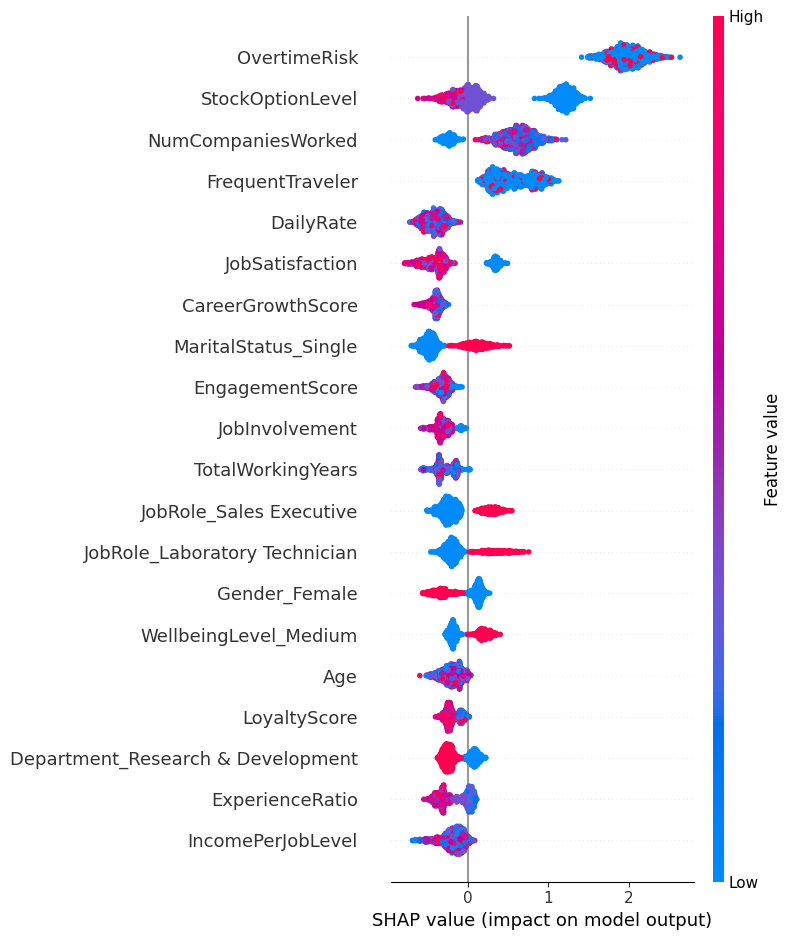

In [50]:
plt.figure()

shap.summary_plot(

    shap_values,
    X,
    show=False

)

plt.tight_layout()

plt.savefig(
    "..//reports//figures//shap//global//summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

#### 7. SHAP Feature Importance

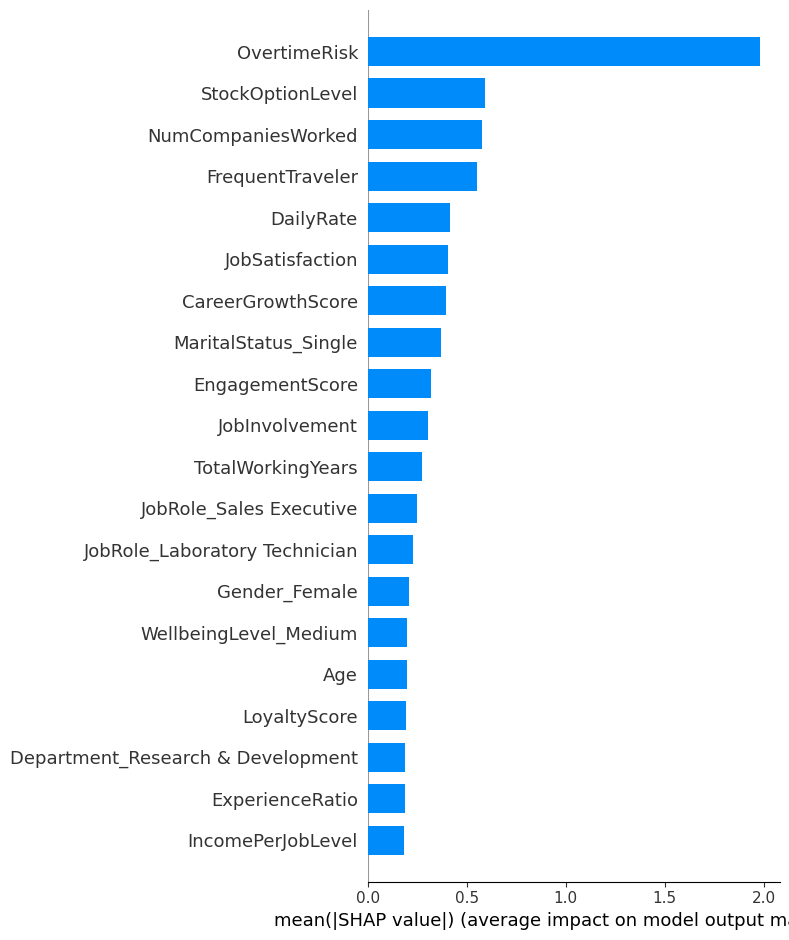

In [51]:
plt.figure()

shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    "..//reports//figures//shap//global//feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

#### 8. Beeswarm Plot

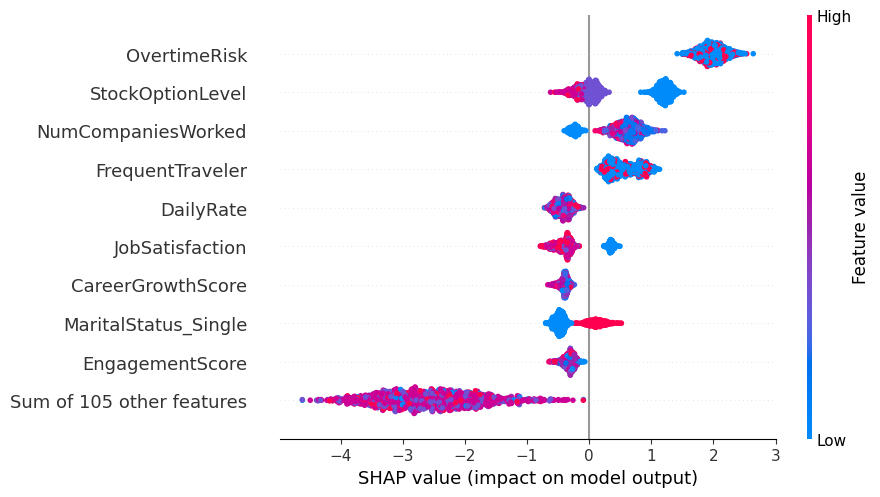

In [52]:
plt.figure()

shap.plots.beeswarm(

    shap.Explanation(
        values=shap_values,
        data=X,
        feature_names=X.columns
    ),

    show=False

)

plt.savefig(
    "..//reports//figures//shap//global//beeswarm_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

#### 9. Top 10 Important Features

In [53]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": np.abs(
        shap_values
    ).mean(axis=0)

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
24,OvertimeRisk,1.983912
15,StockOptionLevel,0.591998
11,NumCompaniesWorked,0.575960
25,FrequentTraveler,0.550443
1,DailyRate,0.414532
8,JobSatisfaction,0.404563
31,CareerGrowthScore,0.396298
64,MaritalStatus_Single,0.370506
29,EngagementScore,0.318228
6,JobInvolvement,0.303057


In [54]:
importance.to_csv(

    "..//reports//tables//shap_feature_importance.csv",

    index=False

)

#### 10. Dependence Plots

We'll do the Top 5 automatically.

In [55]:
top_features = importance.head(5)["Feature"]

In [56]:
for feature in top_features:

    shap.dependence_plot(
        feature,
        shap_values,
        X,
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        f"..//reports//figures//shap//dependence//{feature}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

#### 11. Employee-Level Explanation

Let's explain Employee 0 first.

In [57]:
employee_index = 0

##### Waterfall Plot

In [58]:
shap.plots.waterfall(

    shap.Explanation(
        values=shap_values[employee_index],
        base_values=explainer.expected_value,
        data=X.iloc[employee_index],
        feature_names=X.columns
    ),

    show=False

)

plt.savefig(

    "..//reports//figures//shap//local//waterfall_employee_0.png",

    dpi=300,

    bbox_inches="tight"

)

plt.close()

#### 12. Force Plot

In [59]:
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[employee_index],
    X.iloc[employee_index],
    matplotlib=True,
    show=False
)

plt.savefig(

    "..//reports//figures//shap//local//force_employee_0.png",

    dpi=300,

    bbox_inches="tight"

)

plt.close()

#### 13. Build Employee Explanation Table

In [60]:
probability = model.predict_proba(X)[:, 1]

In [61]:
# Risk Level
risk = pd.cut(

    probability,
    bins=[0, 0.33, 0.66, 1],
    labels=[

        "Low",
        "Medium",
        "High"

    ]

)

In [62]:
# Build Rich SHAP Explanation Table
records = []

for i in range(len(X)):

    employee_shap = shap_values[i]
    abs_importance = np.abs(employee_shap)
    top_indices = np.argsort(abs_importance)[::-1][:3]

    record = {

        "EmployeeID": i + 1,
        "PredictedProbability": round(probability[i], 4),
        "RiskLevel": risk[i]

    }

    for rank, idx in enumerate(top_indices, start=1):

        shap_value = employee_shap[idx]
        record[f"Driver_{rank}"] = X.columns[idx]
        record[f"SHAP_{rank}"] = round(shap_value, 4)
        record[f"FeatureValue_{rank}"] = X.iloc[i, idx]
        record[f"Impact_{rank}"] = (

            "Increases Attrition Risk"
            if shap_value > 0
            else "Reduces Attrition Risk"

        )

    records.append(record)

employee_explanations = pd.DataFrame(records)

In [63]:
# Final Table
employee_explanations.head()

,EmployeeID,PredictedProbability,RiskLevel,Driver_1,SHAP_1,FeatureValue_1,Impact_1,Driver_2,SHAP_2,FeatureValue_2,Impact_2,Driver_3,SHAP_3,FeatureValue_3,Impact_3
0,1,0.5851,Medium,OvertimeRisk,2.1862,1,Increases Attrition Risk,StockOptionLevel,1.1128,0.0,Increases Attrition Risk,MaritalStatus_Single,0.5185,1.0,Increases Attrition Risk
1,2,0.3169,Low,OvertimeRisk,2.0827,0,Increases Attrition Risk,FrequentTraveler,0.9404,1.0,Increases Attrition Risk,NumCompaniesWorked,0.8335,1.0,Increases Attrition Risk
2,3,0.4039,Medium,OvertimeRisk,2.3229,1,Increases Attrition Risk,StockOptionLevel,1.3249,0.0,Increases Attrition Risk,JobSatisfaction,-0.6522,3.0,Reduces Attrition Risk
3,4,0.1763,Low,OvertimeRisk,2.0261,1,Increases Attrition Risk,StockOptionLevel,1.3411,0.0,Increases Attrition Risk,NumCompaniesWorked,0.6331,1.0,Increases Attrition Risk
4,5,0.4298,Medium,OvertimeRisk,1.9883,0,Increases Attrition Risk,FrequentTraveler,0.7550,0.0,Increases Attrition Risk,NumCompaniesWorked,0.6825,9.0,Increases Attrition Risk


In [64]:
employee_explanations.to_csv(

    "..//reports//explanations//employee_shap_explanations.csv",

    index=False

)

print("Employee explanations exported successfully.")

Employee explanations exported successfully.


# Conclusion

This notebook applied Explainable AI (SHAP) to interpret the predictions of the best-performing ADASYN XGBoost model, transforming a high-performing machine learning model into an interpretable decision support system for HR professionals.

### Key Features

- Loaded the production-ready ADASYN XGBoost model developed in the previous modeling phase.
- Generated SHAP values for all **1,470 employees** to explain individual predictions and overall model behavior.
- Created global explainability visualizations including the SHAP Summary Plot, Feature Importance Bar Plot, Beeswarm Plot, and Dependence Plots to identify the primary drivers of employee attrition.
- Produced employee-level explanations using Waterfall and Force Plots to demonstrate how specific employee characteristics influenced individual attrition predictions.
- Ranked the most influential employee attributes using mean absolute SHAP values, providing a transparent understanding of the model's decision-making process.
- Developed a comprehensive explainability dataset for every employee containing:
  - Employee ID
  - Predicted attrition probability
  - Risk category (Low, Moderate, High, Critical)
  - Top three contributing features
  - SHAP contribution scores
  - Original feature values
  - Whether each feature increased or reduced attrition risk
- Exported all explainability visualizations, feature importance tables, and employee-level explanation datasets for integration into Power BI dashboards and future AI applications.

### Explainability Dataset Summary

The exported employee explanation dataset contains one record for each of the **1,470 employees** in the IBM HR Analytics dataset and serves as a bridge between machine learning predictions and business intelligence.

Each employee record includes:

- Predicted attrition probability
- Business-friendly risk classification
- Top three drivers influencing the prediction
- SHAP contribution of each driver
- Original employee feature values
- Positive or negative impact of each feature on attrition risk

This dataset enables HR professionals to understand not only **who is at risk of leaving**, but also **why the model reached that prediction**, supporting transparent and evidence-based decision making.

### Key Findings

- SHAP successfully transformed the XGBoost model from a predictive "black box" into a transparent and interpretable machine learning solution.
- Every employee prediction can now be explained using the most influential factors driving the predicted attrition risk, improving model trust and business adoption.
- Global feature importance identified the organizational factors contributing most to employee attrition, enabling HR teams to prioritize company-wide retention strategies.
- Local explanations provide personalized insights for individual employees, allowing HR professionals to understand the unique reasons behind each prediction.
- The exported explanation dataset establishes a direct connection between predictive analytics and business intelligence, enabling interactive Power BI dashboards, executive reporting, and AI-driven workforce recommendations.

### Business Impact

This notebook bridges predictive analytics and Explainable AI by ensuring every employee prediction is transparent, interpretable, and actionable. Rather than simply identifying employees who are likely to leave, the model now explains the underlying business drivers behind each prediction, empowering HR teams to design targeted retention strategies supported by data-driven evidence.

The next phase of the project will leverage these explainability outputs to build an **AI Workforce Assistant**, capable of generating personalized retention recommendations, career development insights, and executive HR decision support using machine learning predictions and SHAP explanations.